# LIBS

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

: 

In [2]:
# data import 
ds = xr.open_dataset('/home/kauaa/projetos/faculdade/PROJETO INTEGRADOR IV/data/raw/precip_2005_2020.nc')
print(ds)

<xarray.Dataset> Size: 531MB
Dimensions:     (valid_time: 5844, latitude: 141, longitude: 161)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 47kB 2005-01-01 ... 2020-12-31
    expver      (valid_time) <U4 94kB ...
  * latitude    (latitude) float64 1kB 5.0 4.75 4.5 4.25 ... -29.5 -29.75 -30.0
  * longitude   (longitude) float64 1kB -75.0 -74.75 -74.5 ... -35.25 -35.0
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 531MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-09T23:34 GRIB to CDM+CF via cfgrib-0.9.1...


# VISUALIZAÇÃO EM MAPA

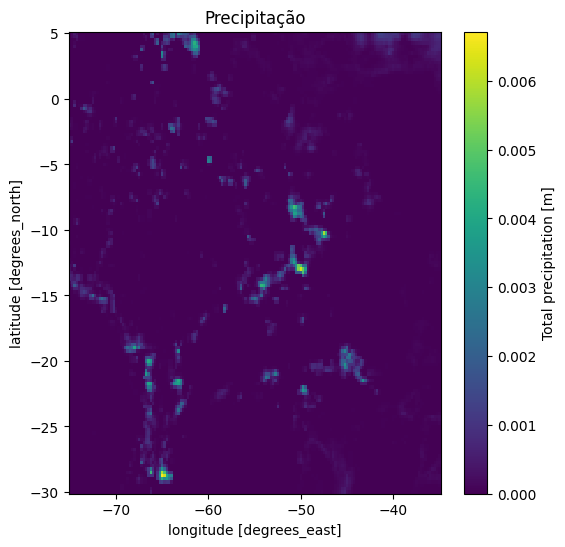

In [5]:
# mapa
tp = ds["tp"]                  # precipitação total
mapa = tp.isel(valid_time=0)   # primeiro dia

# plot
plt.figure(figsize=(6,6))
mapa.plot()
plt.title("Precipitação")
plt.show()

# ALCANÇE DAS AMOSTRAS

In [6]:
print(ds.valid_time.min().values, ds.valid_time.max().values)
print(len(ds.valid_time))

2005-01-01T00:00:00.000000000 2020-12-31T00:00:00.000000000
5844


2005 - 2020

In [7]:
# tamanho do dataset de precipitação
print(ds['tp'].shape)

(5844, 141, 161)


584 imagens, 141 x 161 pixels ≈ 13 milhoes de pixels (aprox. 108mb)

In [8]:
# valores minimos e maximos de precipitação (nao pode ser negativo)
print(tp.min().values, tp.max().values)

0.0 0.055246353


In [9]:
# valores nulos
print(tp.isnull().values.sum())

0


# ANALISE DESCRITIVA

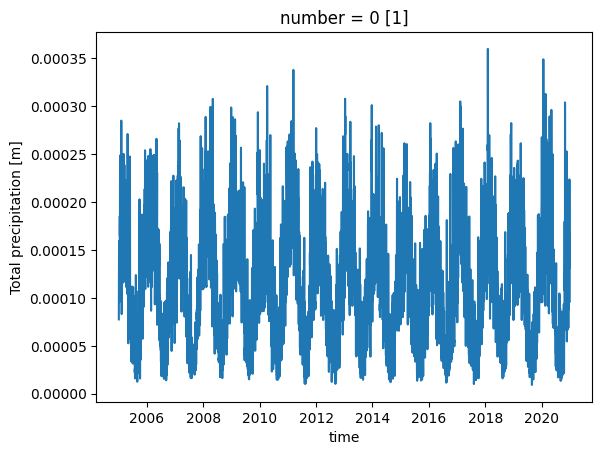

In [10]:
# precipitação média diária
mean_daily = ds.tp.mean(dim=['latitude', 'longitude'])
mean_daily.plot()

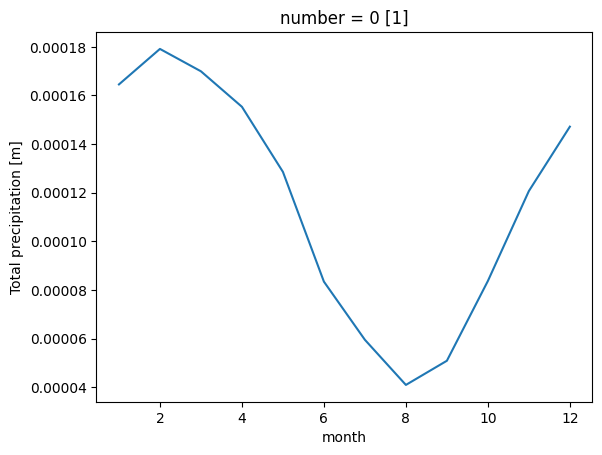

In [11]:
# precipitação média mensal
mean_monthly = mean_daily.groupby('valid_time.month').mean()
mean_monthly.plot()

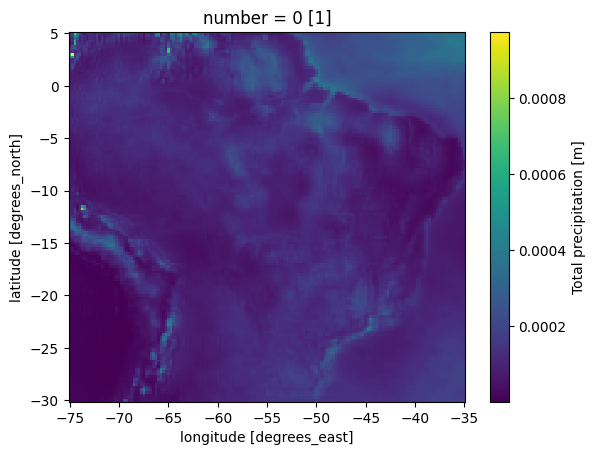

In [12]:
# precipitação média em mapa
mean_map = ds.tp.mean(dim='valid_time')
mean_map.plot()

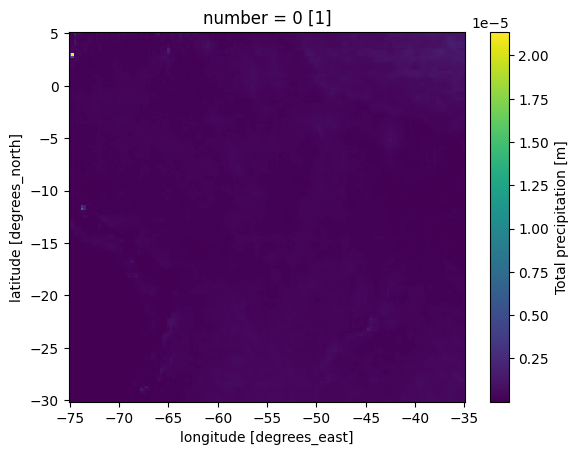

In [13]:
# variancia média em mapa
var_map = ds.tp.var(dim='valid_time')
var_map.plot()

# MÉTRICAS ESPACIAIS

In [18]:
tp_10mm = (ds.tp > 10).mean(dim=['latitude', 'longitude'])
print(pd.Series(tp_10mm).head(10))

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
6    0.0
7    0.0
8    0.0
9    0.0
dtype: float64


In [19]:
space_var = ds.tp.var(dim=['latitude', 'longitude'])
print(pd.Series(space_var).head(10))

0    1.039121e-07
1    1.777160e-07
2    2.150082e-07
3    1.981791e-07
4    2.161798e-07
5    2.258249e-07
6    1.888482e-07
7    2.655597e-07
8    2.570516e-07
9    1.599489e-07
dtype: float32


In [35]:
print("\nmédia diária de precipitação: \n", pd.Series(mean_daily))
print("\ncom uma autocorrelação de: \n", pd.Series(mean_daily).autocorr())


média diária de precipitação: 
 0       0.000078
1       0.000117
2       0.000145
3       0.000159
4       0.000153
          ...   
5839    0.000224
5840    0.000201
5841    0.000151
5842    0.000162
5843    0.000096
Length: 5844, dtype: float32

com uma autocorrelação de: 
 0.8213622172570183
